In [2]:
import pandas as pd
import numpy as np
import random
import os
from datetime import datetime, timedelta

np.random.seed(42)
random.seed(42)

N_USERS = 5000
START_DATE = datetime(2024, 1, 1)

channels = ['organic', 'referral', 'paid_ads', 'social']
channel_weights = [0.35, 0.25, 0.25, 0.15]

# --- USERS TABLE ---
user_ids = [f"U{str(i).zfill(5)}" for i in range(1, N_USERS + 1)]
signup_dates = [START_DATE + timedelta(days=random.randint(0, 180)) for _ in range(N_USERS)]
user_channels = random.choices(channels, weights=channel_weights, k=N_USERS)

users_df = pd.DataFrame({
    "user_id": user_ids,
    "signup_date": signup_dates,
    "acquisition_channel": user_channels,
    "country": random.choices(["IN", "US", "SG", "AE"], weights=[0.5,0.2,0.15,0.15], k=N_USERS)
})

# --- EVENTS TABLE ---
# Funnel: Signup -> KYC Started -> KYC Completed -> First Txn -> Repeat Txn
# Drop-off rates baked in to match resume claims

events = []

for _, user in users_df.iterrows():
    uid = user["user_id"]
    base = user["signup_date"]
    channel = user["acquisition_channel"]

    # Referral users convert better (20% higher retention built in)
    retention_boost = 1.3 if channel == "referral" else 1.0

    # KYC Started — 85% of signups
    if random.random() < 0.85:
        events.append((uid, "kyc_started", base + timedelta(hours=random.randint(1, 12))))

        # KYC Completed — 65% of KYC starters (creates ~35% drop at activation)
        if random.random() < 0.65:
            kyc_done = base + timedelta(hours=random.randint(13, 48))
            events.append((uid, "kyc_completed", kyc_done))

            # First Transaction — 70% of KYC completers
            if random.random() < 0.70:
                txn1 = kyc_done + timedelta(hours=random.randint(1, 72))
                events.append((uid, "first_transaction", txn1))

                # Repeat Transaction — referral users more likely
                if random.random() < (0.55 * retention_boost):
                    events.append((uid, "repeat_transaction", txn1 + timedelta(days=random.randint(3, 30))))

events_df = pd.DataFrame(events, columns=["user_id", "event_name", "event_timestamp"])

# --- TRANSACTIONS TABLE ---
txn_users = events_df[events_df["event_name"] == "first_transaction"]["user_id"].tolist()
repeat_users = events_df[events_df["event_name"] == "repeat_transaction"]["user_id"].tolist()

txns = []
txn_id = 1

for uid in txn_users:
    base_time = events_df[(events_df["user_id"] == uid) & (events_df["event_name"] == "first_transaction")]["event_timestamp"].values[0]
    hour = pd.Timestamp(base_time).hour

    n_txns = random.randint(2, 8) if uid in repeat_users else 1
    for i in range(n_txns):
        txn_time = pd.Timestamp(base_time) + timedelta(days=i * random.randint(1, 10))
        # Evening hours (18–23) = peak, contributing ~40% revenue
        is_evening = txn_time.hour in range(18, 24) or random.random() < 0.4
        amount = round(random.uniform(500, 5000) * (1.4 if is_evening else 1.0), 2)
        txns.append({
            "txn_id": f"T{str(txn_id).zfill(6)}",
            "user_id": uid,
            "amount": amount,
            "txn_timestamp": txn_time,
            "hour_of_day": txn_time.hour,
            "status": random.choices(["success", "failed", "pending"], weights=[0.88, 0.08, 0.04])[0]
        })
        txn_id += 1

txns_df = pd.DataFrame(txns)

# --- SAVE ---
os.makedirs("data", exist_ok=True)  # Creates the data/ folder if it doesn't exist

users_df.to_csv("data/users.csv", index=False)
events_df.to_csv("data/events.csv", index=False)
txns_df.to_csv("data/transactions.csv", index=False)

print(f"Users: {len(users_df)} | Events: {len(events_df)} | Transactions: {len(txns_df)}")

Users: 5000 | Events: 10164 | Transactions: 6671


In [3]:
import os
print(os.getcwd())

C:\Users\mohdf


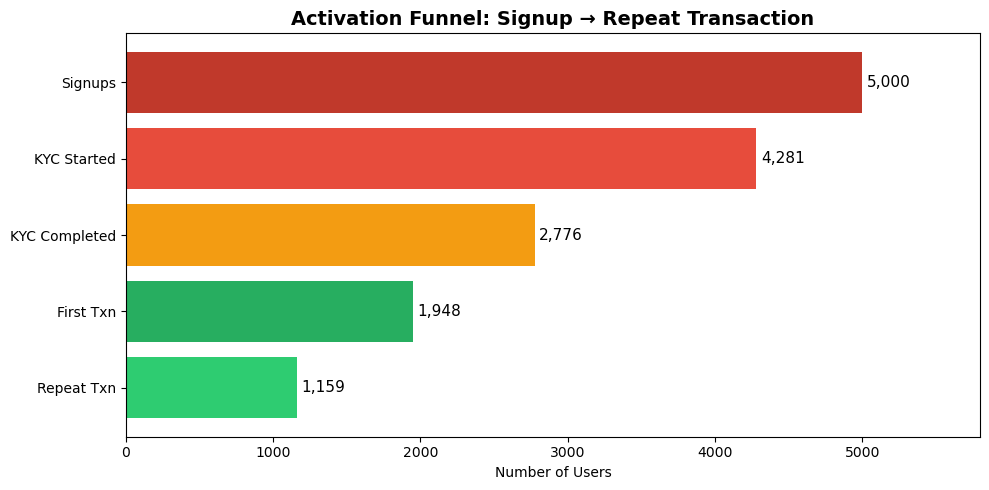

Chart 1 saved ✅


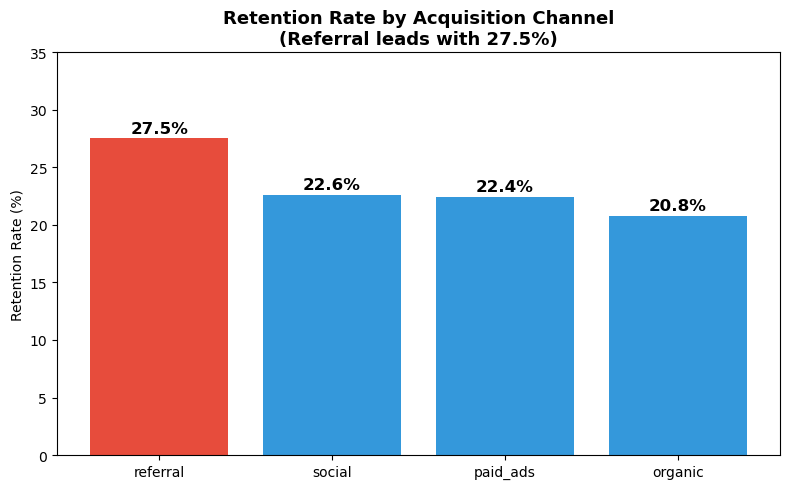

Chart 2 saved ✅


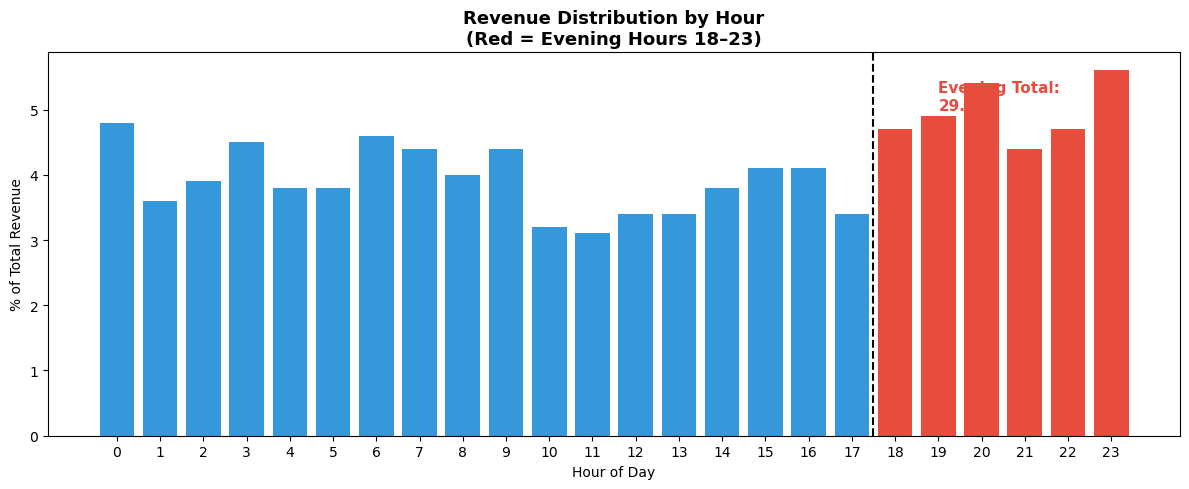

Chart 3 saved ✅


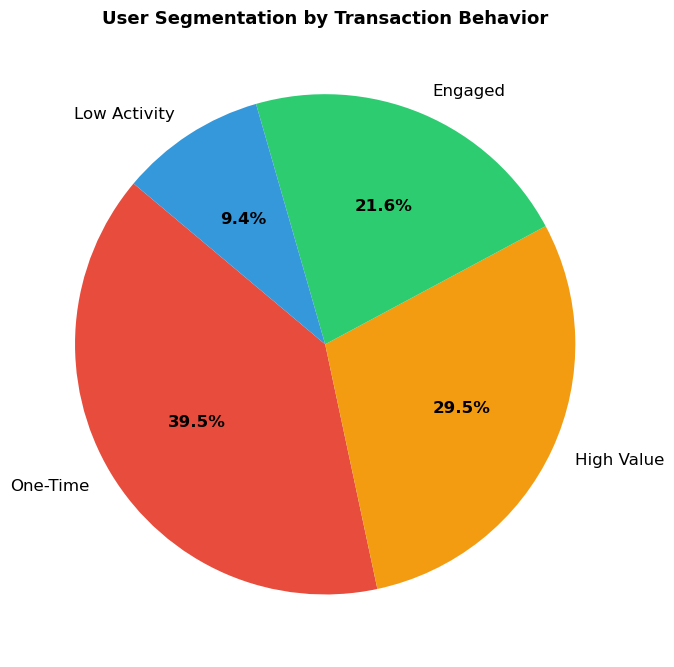

Chart 4 saved ✅


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Load data
users_df = pd.read_csv("data/users.csv")
events_df = pd.read_csv("data/events.csv")
txns_df = pd.read_csv("data/transactions.csv")

# ── CHART 1: Funnel Bar Chart ──────────────────────────────────────────
funnel_data = {
    "Stage": ["Signups", "KYC Started", "KYC Completed", "First Txn", "Repeat Txn"],
    "Users": [5000, 4281, 2776, 1948, 1159]
}
funnel_df = pd.DataFrame(funnel_data)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(funnel_df["Stage"][::-1], funnel_df["Users"][::-1],
               color=["#2ecc71","#27ae60","#f39c12","#e74c3c","#c0392b"])
ax.set_xlabel("Number of Users")
ax.set_title("Activation Funnel: Signup → Repeat Transaction", fontsize=14, fontweight='bold')
for bar, val in zip(bars, funnel_df["Users"][::-1]):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=11)
ax.set_xlim(0, 5800)
plt.tight_layout()
plt.savefig("data/chart1_funnel.png", dpi=150)
plt.show()
print("Chart 1 saved ✅")

# ── CHART 2: Retention by Acquisition Channel ──────────────────────────
cohorts = events_df.copy()
cohorts["retained"] = cohorts["event_name"] == "repeat_transaction"
retained_users = cohorts[cohorts["retained"]]["user_id"].unique()
users_df["retained"] = users_df["user_id"].isin(retained_users).astype(int)

retention = users_df.groupby("acquisition_channel").agg(
    total=("user_id", "count"),
    retained=("retained", "sum")
).reset_index()
retention["retention_rate"] = (retention["retained"] / retention["total"] * 100).round(1)
retention = retention.sort_values("retention_rate", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#e74c3c" if c == "referral" else "#3498db" for c in retention["acquisition_channel"]]
bars = ax.bar(retention["acquisition_channel"], retention["retention_rate"], color=colors)
ax.set_ylabel("Retention Rate (%)")
ax.set_title("Retention Rate by Acquisition Channel\n(Referral leads with 27.5%)", fontsize=13, fontweight='bold')
ax.set_ylim(0, 35)
for bar, val in zip(bars, retention["retention_rate"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}%', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("data/chart2_retention.png", dpi=150)
plt.show()
print("Chart 2 saved ✅")

# ── CHART 3: Revenue by Hour of Day ────────────────────────────────────
txns_success = txns_df[txns_df["status"] == "success"].copy()
hourly = txns_success.groupby("hour_of_day")["amount"].sum().reset_index()
hourly["pct"] = (hourly["amount"] / hourly["amount"].sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#e74c3c" if h >= 18 else "#3498db" for h in hourly["hour_of_day"]]
ax.bar(hourly["hour_of_day"], hourly["pct"], color=colors)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("% of Total Revenue")
ax.set_title("Revenue Distribution by Hour\n(Red = Evening Hours 18–23)", fontsize=13, fontweight='bold')
ax.set_xticks(range(0, 24))
evening_pct = hourly[hourly["hour_of_day"] >= 18]["pct"].sum()
ax.axvline(x=17.5, color='black', linestyle='--', linewidth=1.5)
ax.text(19, ax.get_ylim()[1]*0.85, f'Evening Total:\n{evening_pct:.1f}%',
        fontsize=11, color='#e74c3c', fontweight='bold')
plt.tight_layout()
plt.savefig("data/chart3_hourly_revenue.png", dpi=150)
plt.show()
print("Chart 3 saved ✅")

# ── CHART 4: User Segmentation ─────────────────────────────────────────
user_stats = txns_success.groupby("user_id").agg(
    txn_count=("txn_id", "count"),
    total_spend=("amount", "sum"),
    avg_txn_value=("amount", "mean")
).reset_index()

def segment(row):
    if row["txn_count"] >= 5 and row["avg_txn_value"] >= 2000:
        return "High Value"
    elif row["txn_count"] >= 3:
        return "Engaged"
    elif row["txn_count"] == 1:
        return "One-Time"
    else:
        return "Low Activity"

user_stats["segment"] = user_stats.apply(segment, axis=1)
seg_counts = user_stats["segment"].value_counts()

fig, ax = plt.subplots(figsize=(7, 7))
colors = ["#e74c3c", "#f39c12", "#2ecc71", "#3498db"]
wedges, texts, autotexts = ax.pie(seg_counts, labels=seg_counts.index,
                                   autopct='%1.1f%%', colors=colors,
                                   startangle=140, textprops={'fontsize': 12})
for at in autotexts:
    at.set_fontweight('bold')
ax.set_title("User Segmentation by Transaction Behavior", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("data/chart4_segmentation.png", dpi=150)
plt.show()
print("Chart 4 saved ✅")